In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned/pokemon_cleaned.csv")
df.head()

,ID,Name,Type_1,Type_2,Ability_1,Ability_2,Hidden_Ability,HP,Attack,Defense,Special_Attack,Special_Defense,Speed,Legendary,Mythical,Pseudo_Legendary
0,1,bulbasaur,grass,poison,overgrow,NaN,chlorophyll,45,49,49,65,65,45,False,False,False
1,2,ivysaur,grass,poison,overgrow,NaN,chlorophyll,60,62,63,80,80,60,False,False,False
2,3,venusaur,grass,poison,overgrow,NaN,chlorophyll,80,82,83,100,100,80,False,False,False
3,4,charmander,fire,NaN,blaze,NaN,solar-power,39,52,43,60,50,65,False,False,False
4,5,charmeleon,fire,NaN,blaze,NaN,solar-power,58,64,58,80,65,80,False,False,False


In [2]:
df['Is_Special'] = df[['Legendary', 'Mythical', 'Pseudo_Legendary']].any(axis=1)

In [3]:
df['Is_Special'].value_counts()

Is_Special
False    810
True      88
Name: count, dtype: int64

## Creating Target Variable for Machine Learning

The original dataset contained three separate columns:
- Legendary  
- Mythical  
- Pseudo Legendary  

Since each of these represents a category of rare or powerful Pokémon, they were combined into a single target variable called `Is_Special`.

A Pokémon is labeled as `True` if it belongs to any of these categories, and `False` otherwise.

This approach helps:
- Simplify the classification task  
- Reduce class imbalance  
- Create a more meaningful prediction target

In [4]:
df.groupby('Is_Special')[['HP','Attack','Defense','Special_Attack','Special_Defense','Speed']].mean()

,HP,Attack,Defense,Special_Attack,Special_Defense,Speed
Is_Special,,,,,,
False,66.345679,73.338272,69.064198,65.839506,66.645679,62.855556
True,93.750000,106.056818,97.863636,105.045455,99.613636,94.431818


In [5]:
df['Total_Power'] = df[['HP','Attack','Defense','Special_Attack','Special_Defense','Speed']].sum(axis=1)

In [6]:
df.groupby('Is_Special')['Total_Power'].mean()

Is_Special
False    404.088889
True     596.761364
Name: Total_Power, dtype: float64

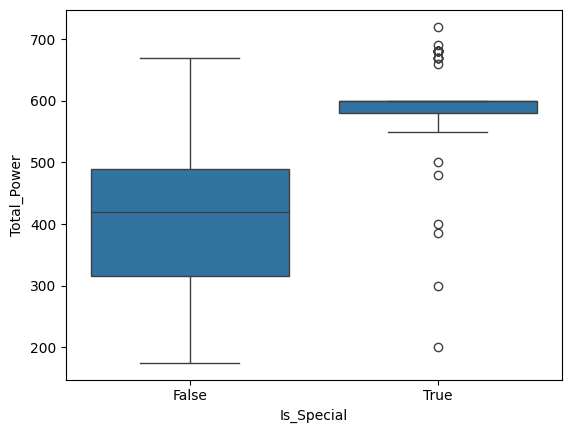

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Is_Special', y='Total_Power', data=df)
plt.show()

## Insight: Power Distribution of Special vs Non-Special Pokémon

Special Pokémon have a significantly higher average total power (596) compared to non-special Pokémon (404).

From the boxplot:
- Non-special Pokémon show a wide range of power levels, indicating high variability
- Special Pokémon are more tightly clustered, mostly within the 570–600 range

This suggests that special Pokémon are not only stronger on average but also more consistent in their strength.

However, a few special Pokémon fall outside this range, indicating some variation within the group.

## Overlap

If I only used Total_Power… could I perfectly classify them?

Total_Power is a strong indicator of whether a Pokémon is special, but it is not sufficient on its own due to overlap between the classes.

Some non-special Pokémon go up to ~650+
Some special Pokémon drop to ~300–400

There is shared territory between the two groups

🧩 What that implies
If you draw a line like:

Total_Power > 500 → Special  
Total_Power ≤ 500 → Not Special

You will:
Misclassify some strong normal Pokémon
Misclassify some weaker special Pokémon

So:
Not perfectly separable
But reasonably separable

In [8]:
df[df['Total_Power'] > 600]['Is_Special'].value_counts()

Is_Special
True     21
False     1
Name: count, dtype: int64

In [9]:
df[df['Total_Power'] < 450]['Is_Special'].value_counts()

Is_Special
False    457
True       4
Name: count, dtype: int64

## Insight: Can Total Power Alone Classify Special Pokémon?

Total Power shows a strong difference between special and non-special Pokémon, with special Pokémon having a much higher average.

However, Total Power alone is not sufficient for perfect classification.

From the distribution:
- Some non-special Pokémon have very high total power (above 600)
- Some special Pokémon have relatively lower total power (around 300–400)

This creates an overlap between the two groups.

As a result:
- A simple threshold on Total Power would lead to misclassification
- Total Power is a strong indicator, but not a perfect separator

This suggests that additional features (such as individual stats or type information) are needed for more accurate classification.

In [10]:
df.groupby('Is_Special')[[
    'HP','Attack','Defense',
    'Special_Attack','Special_Defense','Speed'
]].mean()

,HP,Attack,Defense,Special_Attack,Special_Defense,Speed
Is_Special,,,,,,
False,66.345679,73.338272,69.064198,65.839506,66.645679,62.855556
True,93.750000,106.056818,97.863636,105.045455,99.613636,94.431818


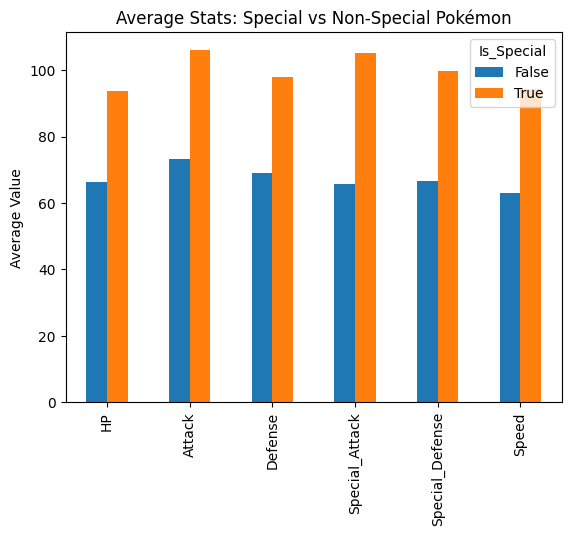

In [11]:
import matplotlib.pyplot as plt

df.groupby('Is_Special')[[
    'HP','Attack','Defense',
    'Special_Attack','Special_Defense','Speed'
]].mean().T.plot(kind='bar')

plt.title("Average Stats: Special vs Non-Special Pokémon")
plt.ylabel("Average Value")
plt.show()

## Insight: Feature-wise Differences Between Special and Non-Special Pokémon

From the comparison of average stats:

- Special Pokémon tend to have higher values across most stats
- Attack and Special Attack show the largest differences between the two groups
- Defense shows a relatively smaller difference, making it a weaker distinguishing feature

This suggests that offensive stats (especially Attack) play a more significant role in differentiating special Pokémon, while defensive stats contribute less to the distinction.

In [12]:
df.groupby('Type_1')['Is_Special'].mean().sort_values(ascending=False)

Type_1
dragon      0.451613
psychic     0.310345
steel       0.266667
flying      0.142857
electric    0.122449
dark        0.111111
fighting    0.111111
ice         0.107143
fairy       0.095238
fire        0.086207
rock        0.080000
ghost       0.064516
ground      0.057143
water       0.056911
grass       0.034884
poison      0.028571
normal      0.027523
bug         0.013333
Name: Is_Special, dtype: float64

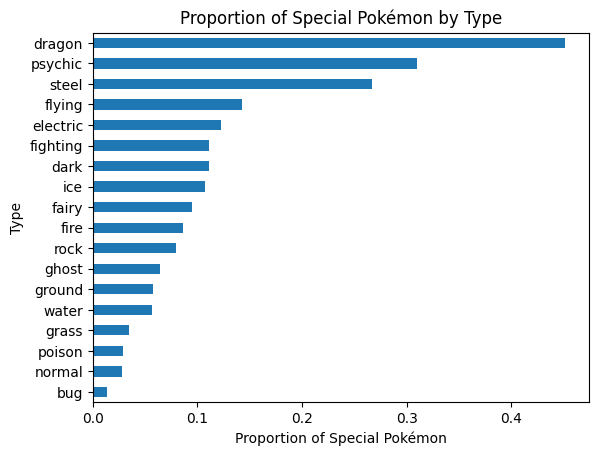

In [13]:
import matplotlib.pyplot as plt

df.groupby('Type_1')['Is_Special'].mean().sort_values().plot(kind='barh')

plt.title("Proportion of Special Pokémon by Type")
plt.xlabel("Proportion of Special Pokémon")
plt.ylabel("Type")
plt.show()

## Insight: Type Distribution of Special Pokémon

The proportion of special Pokémon varies significantly across different types.

Some types have a noticeably higher concentration of special Pokémon, suggesting a strong association between type and rarity/power classification.

On the other hand, certain types rarely appear as special, indicating that they are more common among regular Pokémon.

This suggests that Pokémon type plays a role in determining whether a Pokémon is classified as special.

In [14]:
df['Type_1'].value_counts()

Type_1
water       123
normal      109
grass        86
bug          75
fire         58
psychic      58
rock         50
electric     49
fighting     36
dark         36
poison       35
ground       35
ghost        31
dragon       31
steel        30
ice          28
fairy        21
flying        7
Name: count, dtype: int64

## Insight: Type Distribution and Sample Size Consideration

Types such as Steel and Flying show a high proportion of special Pokémon.

However, these types have relatively fewer total Pokémon in the dataset.

This suggests that while a large percentage of these types are classified as special, the overall sample size is small. As a result, a few special Pokémon can significantly influence the proportion.

Therefore, these patterns should be interpreted with caution, and both proportion and total count should be considered when analyzing type-based trends.

## Correlation Analysis

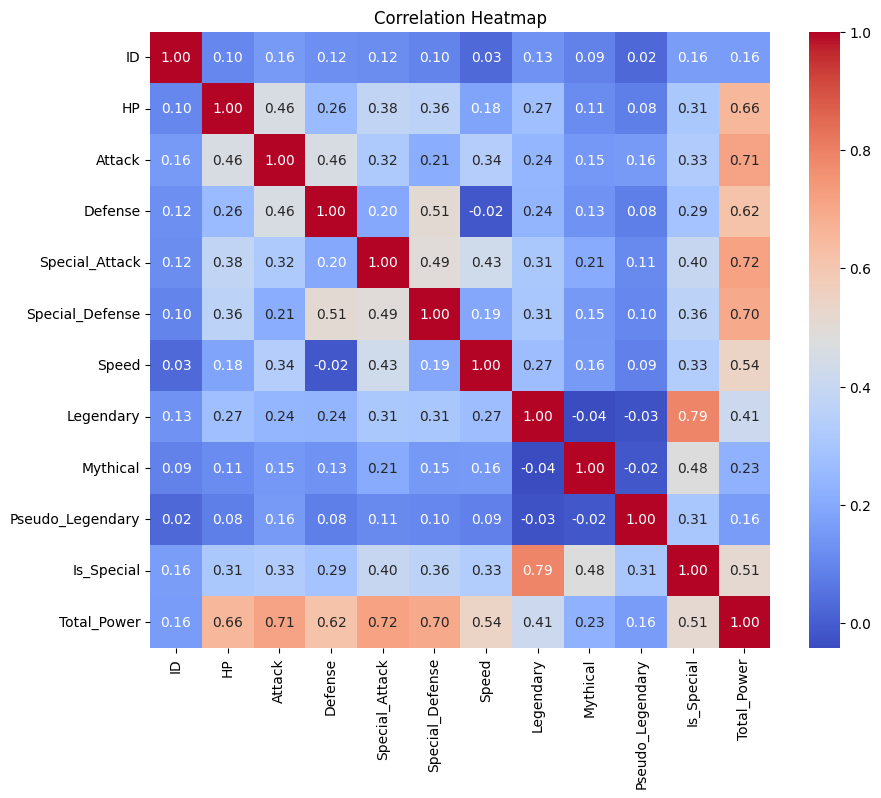

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Insight: Correlation Analysis

The correlation heatmap provides insight into relationships between features.

- The `Legendary` feature shows a strong correlation with `Is_Special` (0.79), which is expected since `Is_Special` is derived from Legendary, Mythical, and Pseudo Legendary categories.

- Among the numerical features, no single stat shows a very strong correlation with `Is_Special`.

- Special Attack (0.40), Special Defense (0.36), Attack (0.33), and Speed (0.33) show moderate positive correlations.

This suggests that being a special Pokémon is not determined by a single dominant stat, but rather by a combination of multiple moderately higher attributes.